In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
user_behavior_df = pd.read_csv(r"C:\Users\abdul\Downloads\user_behavior_dataset.csv")

In [8]:
user_behavior_df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [10]:
user_behavior_df.shape

(700, 11)

In [12]:
user_behavior_df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [14]:
user_behavior_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [16]:
user_behavior_df['Device Model'].unique()

array(['Google Pixel 5', 'OnePlus 9', 'Xiaomi Mi 11', 'iPhone 12',
       'Samsung Galaxy S21'], dtype=object)

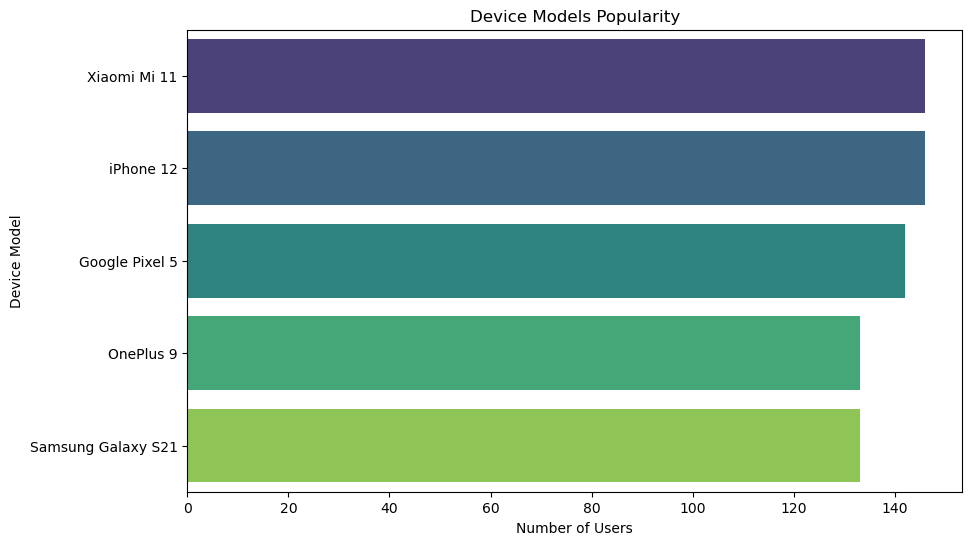

In [190]:
# 2. Device Analysis: Popular Device Models
plt.figure(figsize=(10, 6))
device_counts = user_behavior_df['Device Model'].value_counts().head(10)
sns.barplot(x=device_counts.values, y=device_counts.index,hue=device_counts.index, palette="viridis")
plt.title('Device Models Popularity')
plt.xlabel('Number of Users')
plt.ylabel('Device Model')
plt.show()

<Axes: xlabel='Age', ylabel='Screen On Time (hours/day)'>

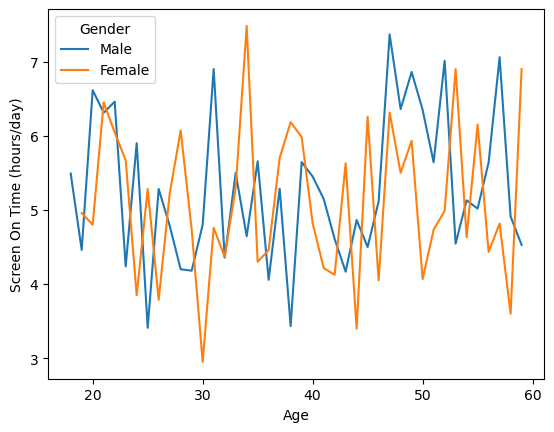

In [24]:
sns.lineplot(x=user_behavior_df['Age'],y=user_behavior_df['Screen On Time (hours/day)'],data=user_behavior_df,hue='Gender',errorbar=None)

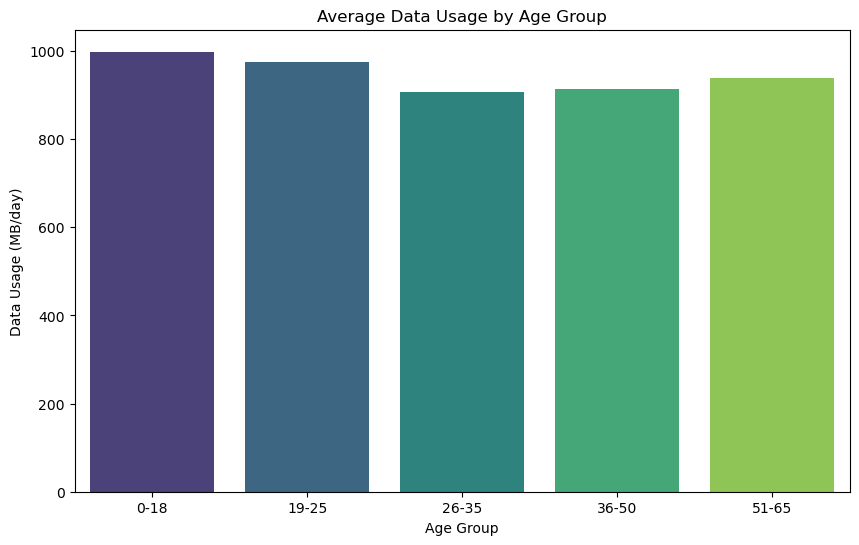

In [44]:
user_behavior_df['Age Group'] = pd.cut(user_behavior_df['Age'], bins=[0, 18, 25, 35, 50, 65], 
                                       labels=['0-18', '19-25', '26-35', '36-50', '51-65'])
plt.figure(figsize=(10, 6))
sns.barplot(data=user_behavior_df, x='Age Group', y='Data Usage (MB/day)', errorbar=None ,palette='viridis',hue='Age Group')
plt.title('Average Data Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Data Usage (MB/day)')
plt.show()

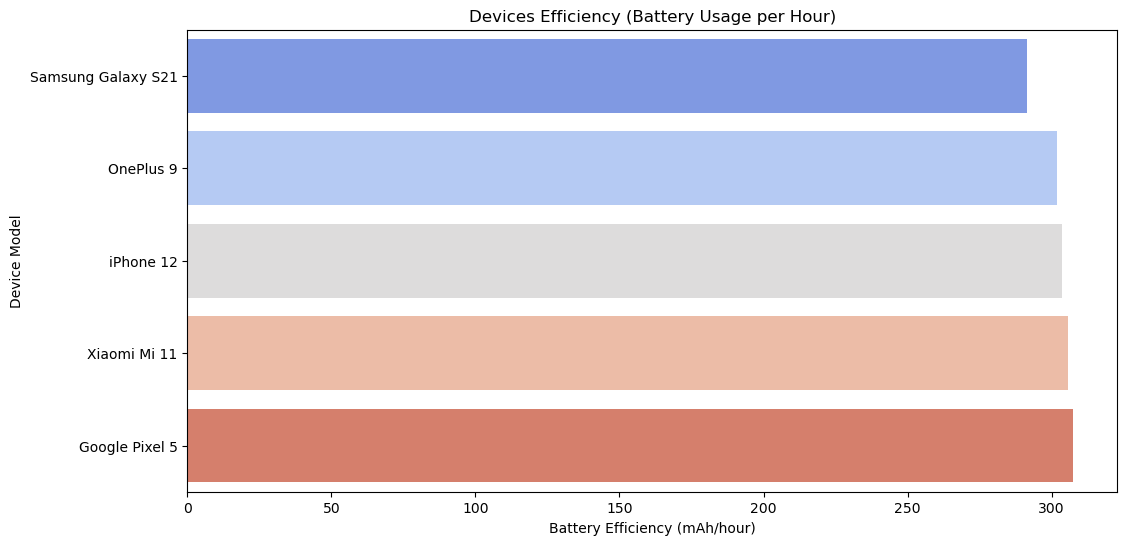

In [18]:
# 2. Battery Efficiency by Device
user_behavior_df['Battery Efficiency (mAh/hour)'] = user_behavior_df['Battery Drain (mAh/day)'] / user_behavior_df['Screen On Time (hours/day)']
plt.figure(figsize=(12, 6))
device_efficiency = user_behavior_df.groupby('Device Model')['Battery Efficiency (mAh/hour)'].mean().sort_values().head(10)
sns.barplot(x=device_efficiency.values, y=device_efficiency.index,hue=device_efficiency.index, palette='coolwarm')
plt.title('Devices Efficiency (Battery Usage per Hour)')
plt.xlabel('Battery Efficiency (mAh/hour)')
plt.ylabel('Device Model')
plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_13728\3983909769.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_users, x='User ID', y='App Usage Time (min/day)', palette='magma')


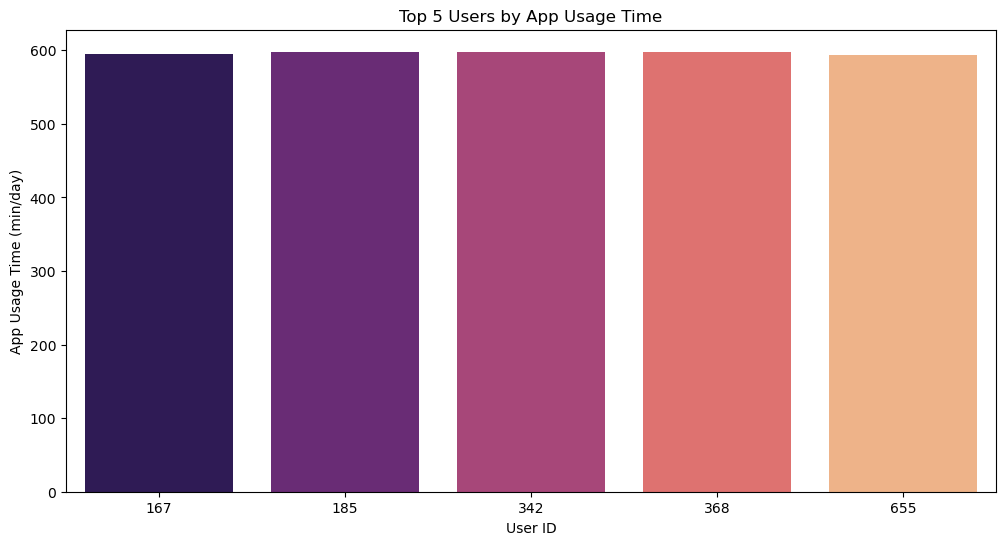

In [50]:
top_users = user_behavior_df.nlargest(5, 'App Usage Time (min/day)')[['User ID', 'App Usage Time (min/day)','Screen On Time (hours/day)', 
                                                                      'Data Usage (MB/day)', 
                                                                      'Battery Drain (mAh/day)']]
plt.figure(figsize=(12, 6))
sns.barplot(data=top_users, x='User ID', y='App Usage Time (min/day)', palette='magma')
plt.title('Top 5 Users by App Usage Time')
plt.xlabel('User ID')
plt.ylabel('App Usage Time (min/day)')
plt.show()